# Análisis Exploratorio de Datos — Reportes Críticos (`rad_criticos`)

Este cuaderno realiza el análisis exploratorio completo del subconjunto de reportes radiológicos clasificados como **Críticos** por el modelo RAD-ALERT (cuaderno `0.1_Inferencia_RAD_ALERT.ipynb`).

**Entrada:** `../data/rad_criticos.xlsx` (952 registros)  
**Objetivo:** Entender la distribución, calidad y características del corpus sobre el que se entrenarán los modelos de clasificación de patologías.

---

### Secciones
1. Configuración e importaciones
2. Carga y visión general
3. Calidad de datos (nulos, duplicados)
4. Puntuación RAD-ALERT
5. Variables binarias y acuerdo con etiqueta original
6. Análisis temporal
7. Longitud de textos
8. Frecuencias y n-gramas (texto limpio)
9. Detección de patologías por reglas
10. Co-ocurrencia y correlaciones

## 1. Configuración e importaciones

In [39]:
from dotenv import load_dotenv
import os

load_dotenv()

DATA_DIR    = os.getenv('DATA_DIR', '../data')
PROCESSED_DATA_PATH    = os.path.join(DATA_DIR, '../data/rad_criticos.xlsx')
RANDOM_SEED = int(os.getenv('RANDOM_SEED', 42))

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import re
import unicodedata
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.dpi'] = 110

## 2. Carga y visión general

In [41]:
df = pd.read_excel('../data/rad_criticos.xlsx')

print(f'Registros: {df.shape[0]}')
print(f'Columnas : {df.shape[1]}')
print()
print('Columnas:', df.columns.tolist())
df.head(3)

Registros: 952
Columnas : 15

Columnas: ['Fecha(dd/mm/yyyy)', 'Modalidad', 'Estudio', 'Técnica', 'Datos Clínicos', 'Hallazgos', 'Opinión', 'Reporte estructurado', 'Estudio Complementario Sugerido', 'Hallazgo Crítico', 'Estudio Normal', 'texto_informe', 'texto_normalizado', 'rad_prediccion', 'rad_score']


,Fecha(dd/mm/yyyy),Modalidad,Estudio,Técnica,Datos Clínicos,Hallazgos,Opinión,Reporte estructurado,Estudio Complementario Sugerido,Hallazgo Crítico,Estudio Normal,texto_informe,texto_normalizado,rad_prediccion,rad_score
0,2019-01-01 00:00:00,CT,tomografia computada de craneo simple,se realizan cortes axiales desde fosa posterio...,politrauma,signos de sangrado. hematoma subdural: no. hem...,hematoma epidural frontal derecho. fractura fr...,1,0,0,0,politrauma signos de sangrado. hematoma subdur...,politrauma signos de sangrado hematoma subdura...,Crítico,0.667506
1,2019-01-01 00:00:00,CT,tomografia computada de craneo simple,se realizan cortes axiales desde fosa posterio...,politrauma,signos de sangrado. hematoma subdural: no. hem...,foco de contusión en el lóbulo frontal izquier...,1,0,1,0,politrauma signos de sangrado. hematoma subdur...,politrauma signos de sangrado hematoma subdura...,Crítico,0.927720
2,2019-01-01 00:00:00,CT,tomografia computada de craneo simple,se realizan cortes axiales desde fosa posterio...,politrauma,signos de sangrado. hematoma subdural: laminar...,hematoma epidural frontal derecho y hematoma s...,1,0,1,0,politrauma signos de sangrado. hematoma subdur...,politrauma signos de sangrado hematoma subdura...,Crítico,0.972965


In [42]:
df.dtypes

Fecha(dd/mm/yyyy)                   object
Modalidad                           object
Estudio                             object
Técnica                             object
Datos Clínicos                      object
Hallazgos                           object
Opinión                             object
Reporte estructurado                 int64
Estudio Complementario Sugerido      int64
Hallazgo Crítico                     int64
Estudio Normal                       int64
texto_informe                       object
texto_normalizado                   object
rad_prediccion                      object
rad_score                          float64
dtype: object

In [43]:
df.describe(include='all')

,Fecha(dd/mm/yyyy),Modalidad,Estudio,Técnica,Datos Clínicos,Hallazgos,Opinión,Reporte estructurado,Estudio Complementario Sugerido,Hallazgo Crítico,Estudio Normal,texto_informe,texto_normalizado,rad_prediccion,rad_score
count,952,952,952,952,952,952,952,952.000000,952.000000,952.000000,952.000000,952,952,952,952.000000
unique,613,1,4,537,674,907,905,NaN,NaN,NaN,NaN,923,909,1,NaN
top,2025-05-02 00:00:00,CT,tomografia computada de craneo simple,se realizan cortes axiales desde fosa posterio...,código acv,signos de sangrado. hematoma subdural: no. hem...,contusión frontobasal derecha sin edema vasogé...,NaN,NaN,NaN,NaN,trauma de alta energía. accidente de tránsito....,trauma de alta energia accidente de transito m...,Crítico,NaN
freq,11,952,947,96,88,4,4,NaN,NaN,NaN,NaN,3,4,952,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.299370,0.053571,0.899160,0.005252,NaN,NaN,NaN,0.931522
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.458223,0.225288,0.301275,0.072319,NaN,NaN,NaN,0.097856
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.503739
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,0.000000,NaN,NaN,NaN,0.950370
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,0.000000,NaN,NaN,NaN,0.969943
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,1.000000,0.000000,NaN,NaN,NaN,0.975891


## 3. Calidad de datos

In [44]:
# Valores nulos
nulos = df.isnull().sum().rename('nulos')
pct   = (df.isnull().mean() * 100).round(2).rename('%')
resumen_nulos = pd.concat([nulos, pct], axis=1)
resumen_nulos[resumen_nulos['nulos'] > 0]

,nulos,%


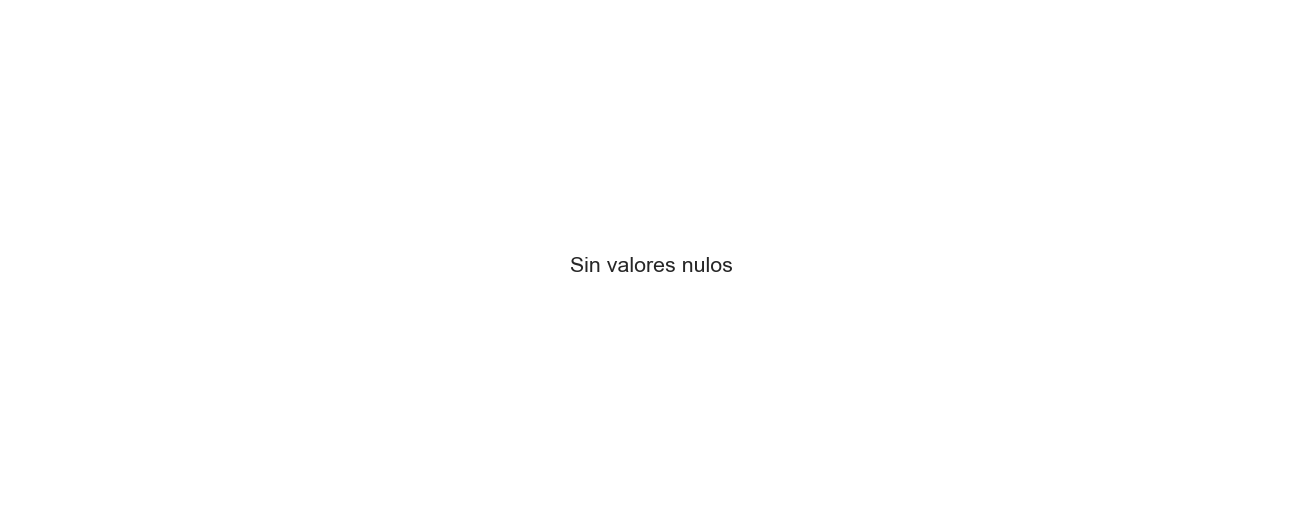

In [45]:
# Visualizar mapa de nulos
fig, ax = plt.subplots(figsize=(12, 5))
cols_nulos = resumen_nulos[resumen_nulos['nulos'] > 0].index.tolist()
if cols_nulos:
    sns.heatmap(
        df[cols_nulos].isnull().astype(int),
        cbar=False, yticklabels=False, ax=ax,
        cmap='Reds'
    )
    ax.set_title('Mapa de valores nulos en columnas con ausencias', fontsize=13)
else:
    ax.text(0.5, 0.5, 'Sin valores nulos', ha='center', va='center', fontsize=14)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [46]:
# Duplicados
dup = df.duplicated().sum()
print(f'Registros duplicados (todas las columnas): {dup}')

dup_texto = df.duplicated(subset=['texto_normalizado']).sum()
print(f'Registros con texto_normalizado duplicado: {dup_texto}')

Registros duplicados (todas las columnas): 6
Registros con texto_normalizado duplicado: 43


## 4. Puntuación RAD-ALERT (`rad_score`)

In [47]:
print('Estadísticas descriptivas de rad_score:')
print(df['rad_score'].describe().round(4))

Estadísticas descriptivas de rad_score:
count    952.0000
mean       0.9315
std        0.0979
min        0.5037
25%        0.9504
50%        0.9699
75%        0.9759
max        0.9799
Name: rad_score, dtype: float64


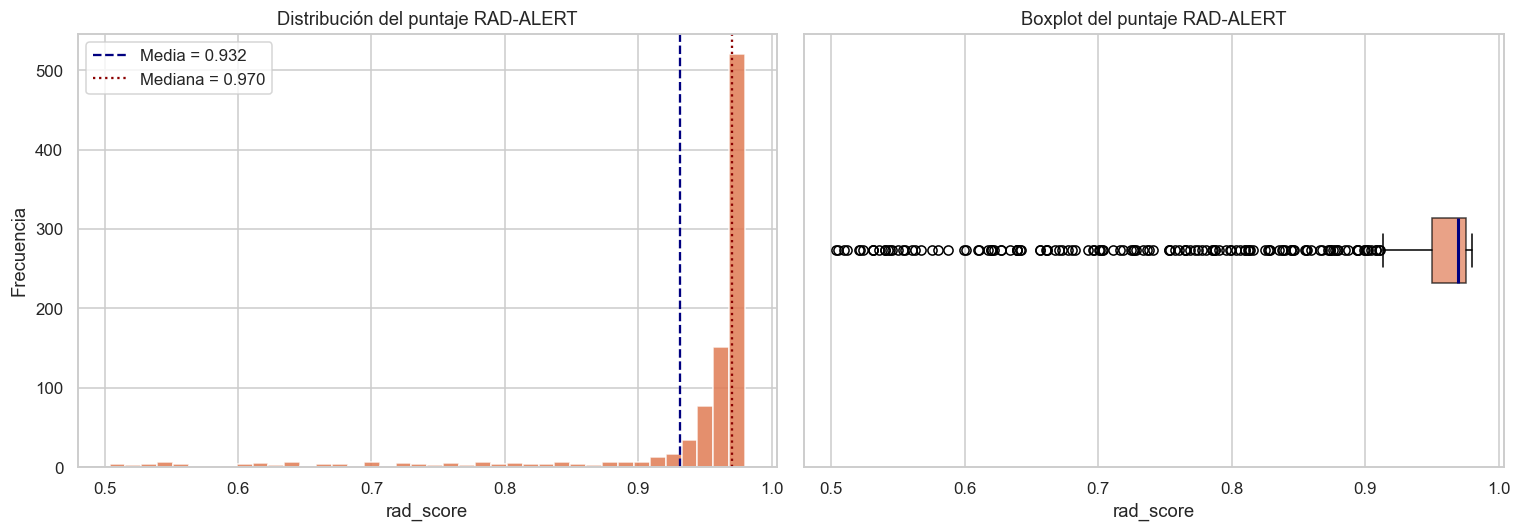

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma + KDE
axes[0].hist(df['rad_score'], bins=40, color='#e07b54', edgecolor='white', alpha=0.85)
axes[0].axvline(df['rad_score'].mean(), color='navy', linestyle='--', linewidth=1.5,
                label=f'Media = {df["rad_score"].mean():.3f}')
axes[0].axvline(df['rad_score'].median(), color='darkred', linestyle=':', linewidth=1.5,
                label=f'Mediana = {df["rad_score"].median():.3f}')
axes[0].set_title('Distribución del puntaje RAD-ALERT', fontsize=12)
axes[0].set_xlabel('rad_score')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['rad_score'].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='#e07b54', alpha=0.7),
                medianprops=dict(color='navy', linewidth=2))
axes[1].set_title('Boxplot del puntaje RAD-ALERT', fontsize=12)
axes[1].set_xlabel('rad_score')
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

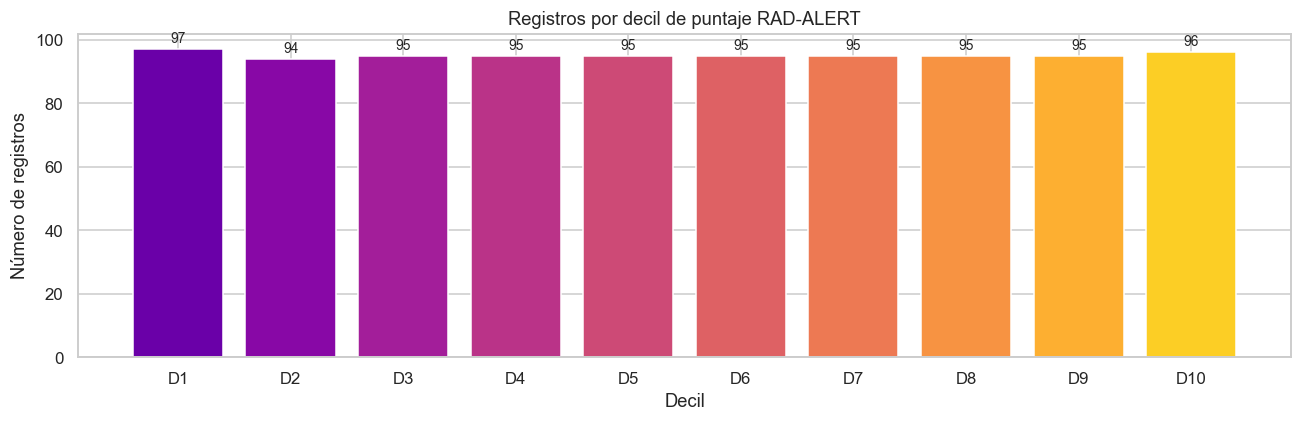

In [49]:
# Distribución por deciles
df['rad_score_decil'] = pd.qcut(df['rad_score'], q=10, labels=[
    'D1','D2','D3','D4','D5','D6','D7','D8','D9','D10'
])

fig, ax = plt.subplots(figsize=(12, 4))
counts = df['rad_score_decil'].value_counts().sort_index()
ax.bar(counts.index, counts.values, color=cm.plasma(np.linspace(0.2, 0.9, 10)), edgecolor='white')
for i, v in enumerate(counts.values):
    ax.text(i, v + 2, str(v), ha='center', fontsize=9)
ax.set_title('Registros por decil de puntaje RAD-ALERT', fontsize=12)
ax.set_xlabel('Decil')
ax.set_ylabel('Número de registros')
plt.tight_layout()
plt.show()

## 5. Variables binarias y acuerdo con la etiqueta original

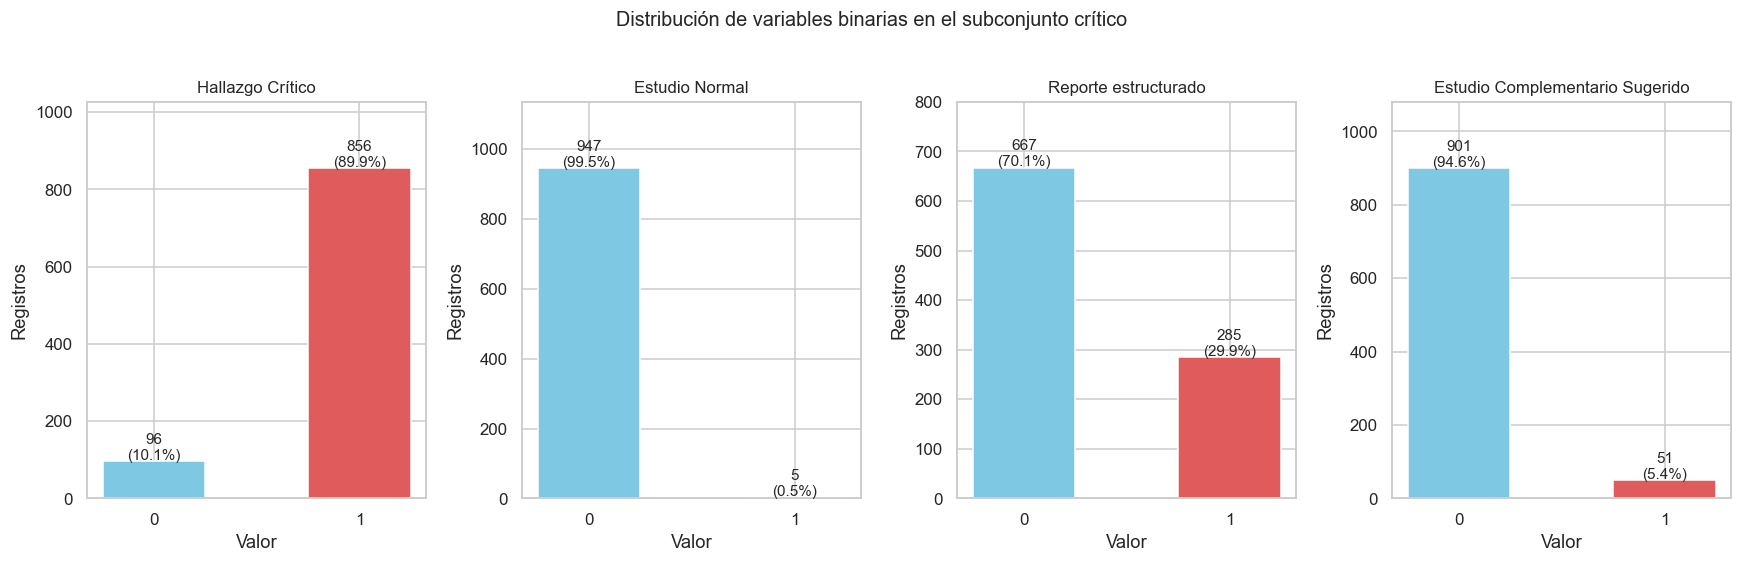

In [50]:
binary_cols = [
    'Hallazgo Crítico',
    'Estudio Normal',
    'Reporte estructurado',
    'Estudio Complementario Sugerido'
]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, col in zip(axes, binary_cols):
    counts = df[col].value_counts().sort_index()
    colors = ['#7ec8e3', '#e05c5c']
    bars = ax.bar(counts.index.astype(str), counts.values,
                  color=colors[:len(counts)], edgecolor='white', width=0.5)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                f'{v}\n({100*v/len(df):.1f}%)', ha='center', fontsize=10)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Registros')
    ax.set_ylim(0, counts.max() * 1.2)

plt.suptitle('Distribución de variables binarias en el subconjunto crítico', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [51]:
# Acuerdo entre RAD-ALERT y etiqueta original 'Hallazgo Crítico'
df_acuerdo = df['Hallazgo Crítico'].value_counts().rename_axis('Hallazgo Crítico original').reset_index()
df_acuerdo.columns = ['Hallazgo Crítico original', 'Count']
df_acuerdo['%'] = (df_acuerdo['Count'] / len(df) * 100).round(1)
print('Dentro de los 952 registros que RAD-ALERT clasifica como Críticos:')
print(df_acuerdo.to_string(index=False))
print()

acuerdo = df['Hallazgo Crítico'].sum()
desacuerdo = len(df) - acuerdo
print(f'Acuerdo (ambos = crítico)  : {acuerdo} ({100*acuerdo/len(df):.1f}%)')
print(f'Discrepancia (RAD=1, orig=0): {desacuerdo} ({100*desacuerdo/len(df):.1f}%)')

Dentro de los 952 registros que RAD-ALERT clasifica como Críticos:
 Hallazgo Crítico original  Count    %
                         1    856 89.9
                         0     96 10.1

Acuerdo (ambos = crítico)  : 856 (89.9%)
Discrepancia (RAD=1, orig=0): 96 (10.1%)


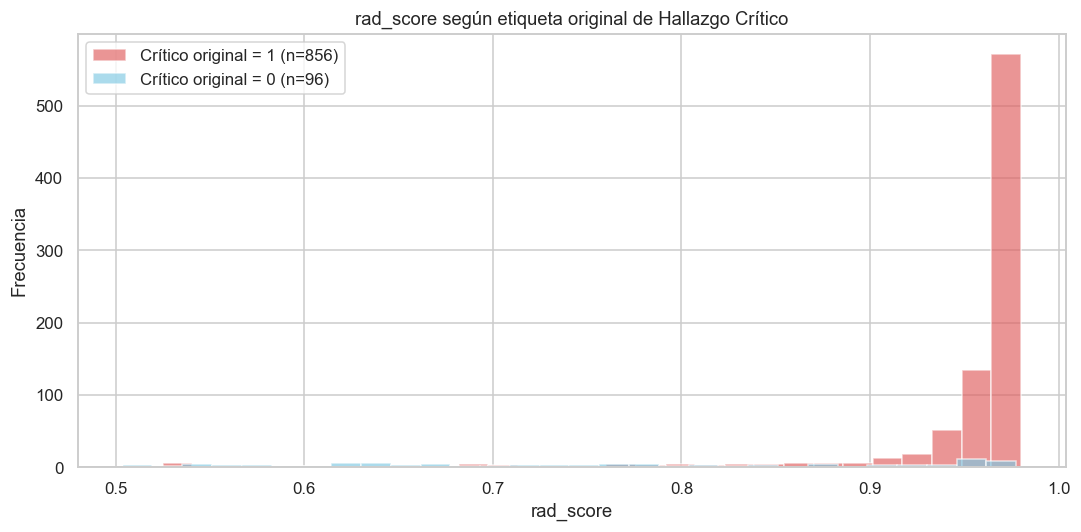

In [52]:
# Distribución de rad_score según Hallazgo Crítico original
fig, ax = plt.subplots(figsize=(10, 5))

for val, color, label in [(1, '#e05c5c', 'Crítico original = 1'), (0, '#7ec8e3', 'Crítico original = 0')]:
    subset = df[df['Hallazgo Crítico'] == val]['rad_score']
    ax.hist(subset, bins=30, alpha=0.65, color=color, edgecolor='white', label=f'{label} (n={len(subset)})')

ax.set_title('rad_score según etiqueta original de Hallazgo Crítico', fontsize=12)
ax.set_xlabel('rad_score')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Análisis temporal

In [53]:
df['Fecha'] = pd.to_datetime(df['Fecha(dd/mm/yyyy)'], errors='coerce')
df['Año']   = df['Fecha'].dt.year
df['Mes']   = df['Fecha'].dt.month

print('Rango temporal:')
print(f'  Desde: {df["Fecha"].min().date()}')
print(f'  Hasta: {df["Fecha"].max().date()}')
print(f'  Registros sin fecha válida: {df["Fecha"].isna().sum()}')

Rango temporal:
  Desde: 2009-07-06
  Hasta: 2025-06-30
  Registros sin fecha válida: 1


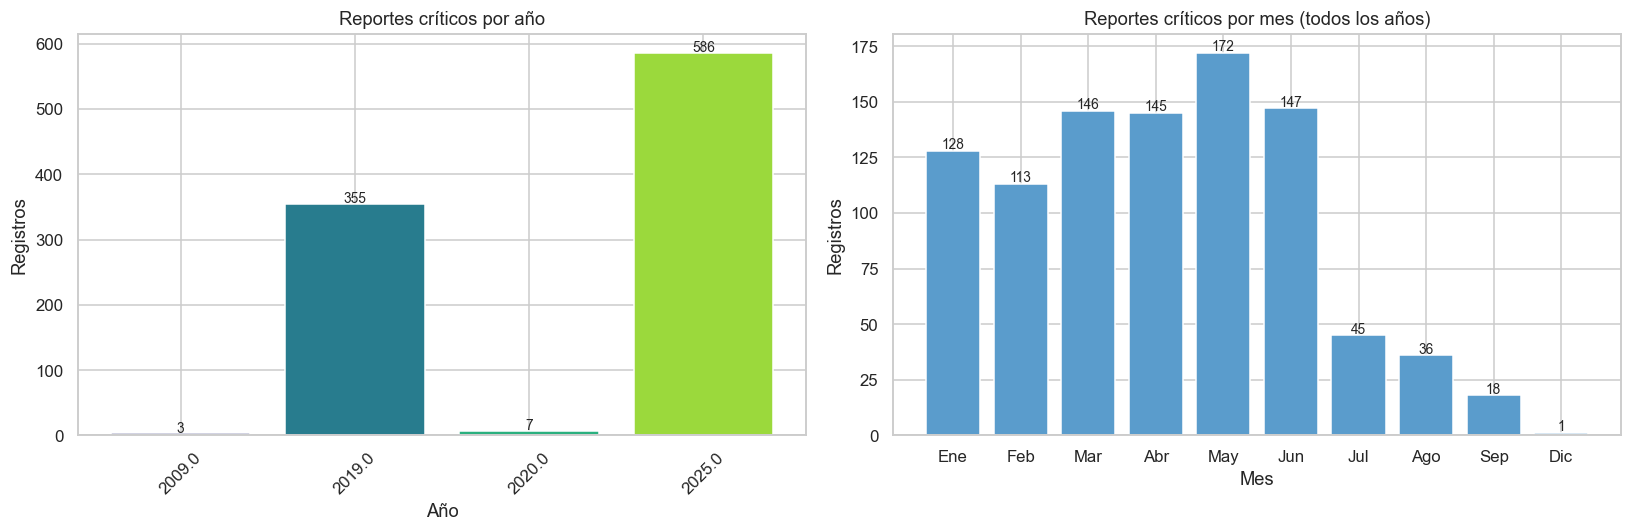

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Por año
por_anio = df['Año'].value_counts().sort_index()
axes[0].bar(por_anio.index.astype(str), por_anio.values,
            color=cm.viridis(np.linspace(0.2, 0.85, len(por_anio))), edgecolor='white')
for i, v in enumerate(por_anio.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontsize=9)
axes[0].set_title('Reportes críticos por año', fontsize=12)
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Registros')
axes[0].tick_params(axis='x', rotation=45)

# Por mes (acumulado)
por_mes = df['Mes'].value_counts().sort_index()
meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
indices_mes = [m for m in por_mes.index if 1 <= m <= 12]
labels_mes  = [meses[int(m) - 1] for m in indices_mes]
axes[1].bar(labels_mes, por_mes[indices_mes].values,
            color='#5a9ccc', edgecolor='white')
for i, v in enumerate(por_mes[indices_mes].values):
    axes[1].text(i, v + 1, str(v), ha='center', fontsize=9)
axes[1].set_title('Reportes críticos por mes (todos los años)', fontsize=12)
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Registros')

plt.tight_layout()
plt.show()

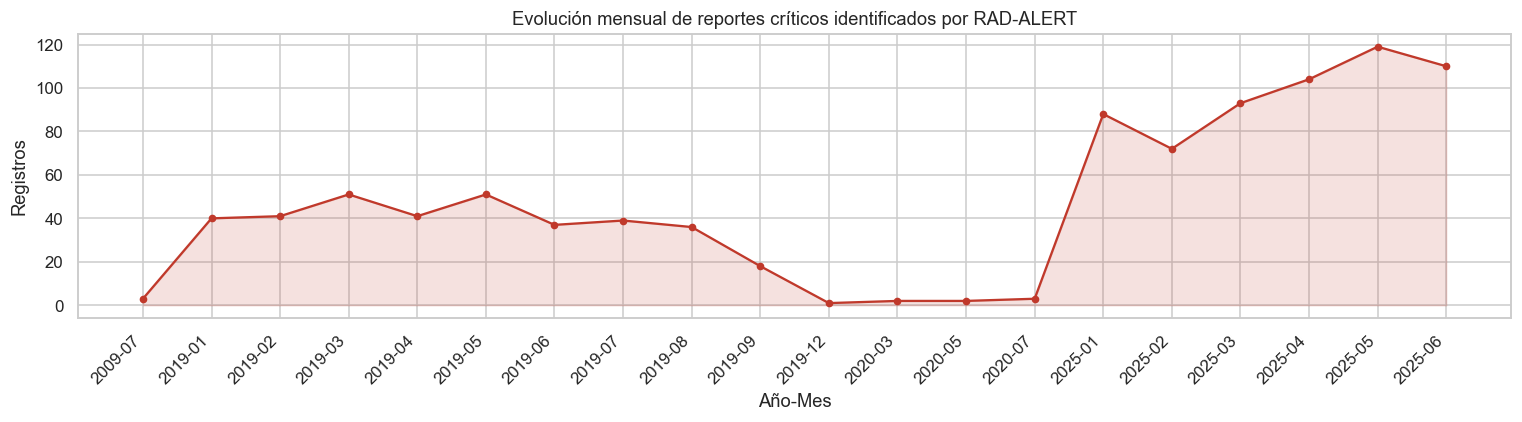

In [55]:
# Serie temporal mensual
df_temp = df.dropna(subset=['Fecha']).copy()
df_temp['YearMonth'] = df_temp['Fecha'].dt.to_period('M')
serie = df_temp.groupby('YearMonth').size()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(serie.index.astype(str), serie.values, marker='o', markersize=4,
        color='#c0392b', linewidth=1.5)
ax.fill_between(range(len(serie)), serie.values, alpha=0.15, color='#c0392b')
ax.set_title('Evolución mensual de reportes críticos identificados por RAD-ALERT', fontsize=12)
ax.set_xlabel('Año-Mes')
ax.set_ylabel('Registros')
step = max(1, len(serie) // 15)
ax.set_xticks(range(0, len(serie), step))
ax.set_xticklabels(serie.index[::step].astype(str), rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 7. Longitud de textos

In [56]:
text_cols = ['Datos Clínicos', 'Hallazgos', 'Opinión', 'texto_normalizado']

for col in text_cols:
    df[f'len_{col.replace(" ","_").replace("ó","o")}'] = (
        df[col].fillna('').astype(str).str.split().str.len()
    )

len_cols = [c for c in df.columns if c.startswith('len_')]
print(df[len_cols].describe().round(1))

       len_Datos_Clínicos  len_Hallazgos  len_Opinion  len_texto_normalizado
count               952.0          952.0        952.0                  952.0
mean                  5.4          152.3         30.4                  188.2
std                   6.6           64.3         16.7                   74.2
min                   1.0           14.0          1.0                   41.0
25%                   2.0          107.8         19.0                  137.0
50%                   4.0          138.0         27.0                  175.0
75%                   7.0          182.0         36.2                  218.0
max                 133.0          577.0        132.0                  659.0


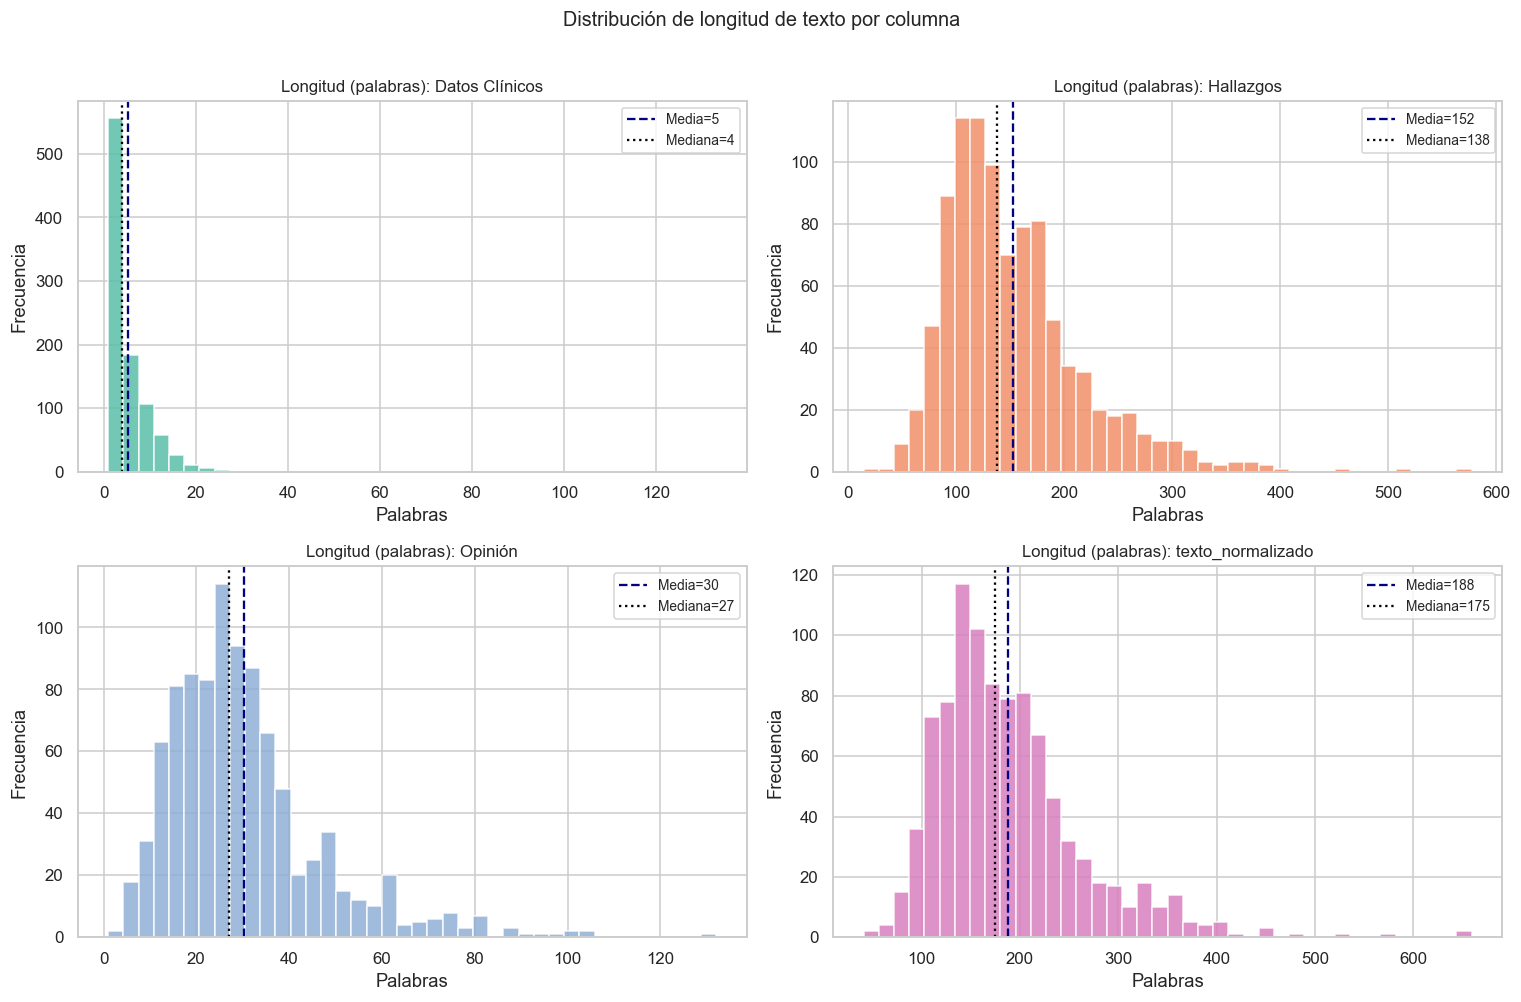

In [57]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

paleta = ['#5bbfa8', '#f0906a', '#8fafd6', '#d87fbf']

for ax, col, color in zip(axes, text_cols, paleta):
    lc = f'len_{col.replace(" ","_").replace("ó","o")}'
    data = df[lc].dropna()
    ax.hist(data, bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(),   color='navy',  linestyle='--', linewidth=1.5,
               label=f'Media={data.mean():.0f}')
    ax.axvline(data.median(), color='black', linestyle=':',  linewidth=1.5,
               label=f'Mediana={data.median():.0f}')
    ax.set_title(f'Longitud (palabras): {col}', fontsize=11)
    ax.set_xlabel('Palabras')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)

plt.suptitle('Distribución de longitud de texto por columna', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

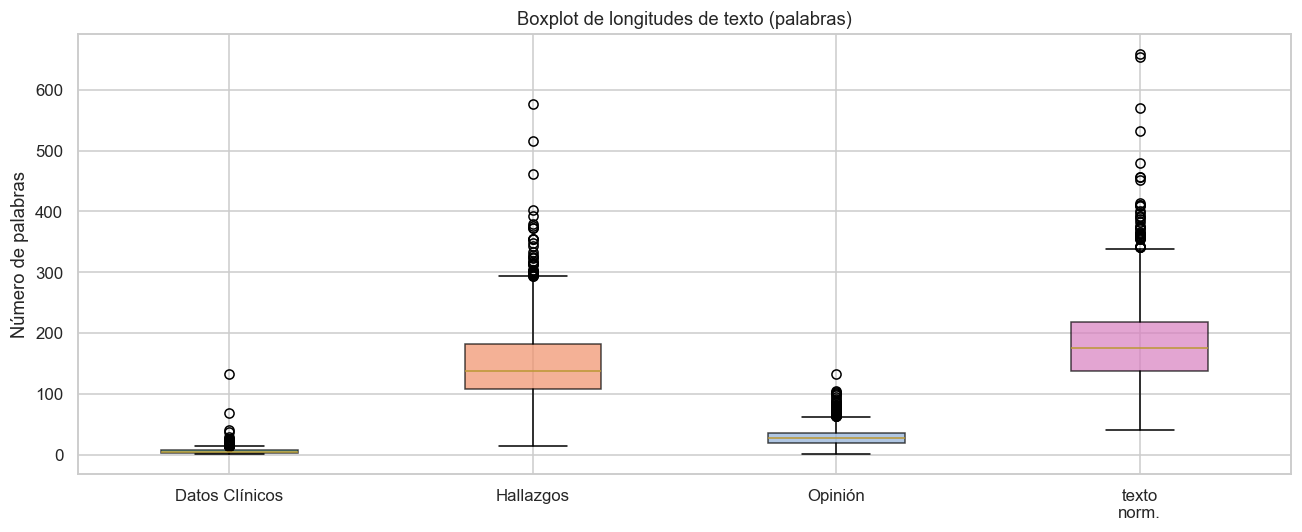

In [58]:
# Boxplots comparativos
fig, ax = plt.subplots(figsize=(12, 5))
data_box = [df[f'len_{c.replace(" ","_").replace("ó","o")}'].dropna() for c in text_cols]
bp = ax.boxplot(data_box, patch_artist=True, vert=True,
                labels=[c.replace('texto_normalizado','texto\nnorm.') for c in text_cols])

for patch, color in zip(bp['boxes'], paleta):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Boxplot de longitudes de texto (palabras)', fontsize=12)
ax.set_ylabel('Número de palabras')
plt.tight_layout()
plt.show()

## 8. Frecuencias de texto y n-gramas

In [59]:
# Re-aplicar limpieza de texto médico (misma función del cuaderno 0)
STOPWORDS_ES = {
    'el','la','los','las','un','una','unos','unas',
    'a','ante','bajo','con','contra','de','desde','durante',
    'en','entre','hacia','hasta','mediante','para','por','segun',
    'sin','sobre','tras','versus','via',
    'e','ni','o','u','y','pero','sino','aunque','porque',
    'como','cuando','donde','que','si','ya','tanto',
    'al','del','lo','le','les','me','mi','mis','nos','se',
    'su','sus','te','tu','tus','yo','ella','ellos','ellas',
    'este','esta','estos','estas','ese','esa','esos','esas',
    'aquel','aquella','aquellos','aquellas',
    'es','son','era','fue','ser','estar','hay','ha','han',
    'he','haber','tiene','tienen','tenia','tendria',
    'no','mas','muy','bien','mal','solo','tambien',
    'ademas','aun','incluso','asi',
    'todo','toda','todos','todas','otro','otra','otros','otras',
    'mismo','misma','mismos','mismas','cada','cualquier',
    'algunos','algunas','algun','ningun',
    'uno','dos','tres','cuatro','cinco','primer','segundo',
}

VERBOS_REPORTE = {
    'observa','observan','evidencia','evidencian','identifica','identifican',
    'aprecia','aprecian','visualiza','visualizan','demuestra','demuestran',
    'nota','notan','detecta','detectan','documenta','documentan',
    'describe','describen','reporta','reportan','muestra','muestran',
    'presenta','presentan','sugiere','sugieren','corresponde','corresponden',
    'recomienda','recomiendan','correlacione','correlaciona','concluye',
    'impresiona','impresionan',
}

TEMPORALES = {
    'previo','previa','previos','previas','anterior','anteriores',
    'posterior','posteriores','siguiente','siguientes','reciente','recientes',
    'actual','actuales','nuevo','nueva','nuevos','nuevas',
    'antiguo','antigua','antiguos','antiguas','cronico','cronica',
    'residual','residuales','secuela','secuelas','estable','estables',
    'conocido','conocida','conocidos','conocidas',
}

FRASES_RUIDO = [
    r'\bhay evidencia\b',r'\bse evidencia\b',r'\bse observa\b',r'\bse observan\b',
    r'\bse identifica\b',r'\bse identifican\b',r'\bse aprecia\b',r'\bse aprecian\b',
    r'\bse visualiza\b',r'\bse visualizan\b',r'\bse demuestra\b',r'\bse demuestran\b',
    r'\bcompatible con\b',r'\bcompatibles con\b',r'\bsugestivo de\b',r'\bsugestiva de\b',
    r'\ben relacion con\b',r'\bcorresponde a\b',r'\bcorresponden a\b',
    r'\ba descartar\b',r'\bpor descartar\b',r'\ba considerar\b',
    r'\bestudio previo\b',r'\bestudios previos\b',r'\bestudio anterior\b',
    r'\bsin alteraciones\b',r'\bsin hallazgos\b',r'\bsin cambios\b',
    r'\bsin evidencia\b',r'\bsin signos\b',
    r'\bse recomienda\b',r'\bse sugiere\b',r'\bse correlacione\b',
    r'\bpor lo anterior\b',r'\bpor lo tanto\b',
    r'\bimpresion diagnostica\b',r'\bhallazgos:\b',r'\bopinion:\b',r'\btecnica:\b',
]

def limpiar_texto_medico(texto, min_longitud_token=3):
    if not isinstance(texto, str) or not texto.strip():
        return ''
    texto = texto.lower().strip()
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )
    for patron in FRASES_RUIDO:
        texto = re.sub(patron, ' ', texto, flags=re.IGNORECASE)
    texto = re.sub(r'[^a-z\s]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    todas_sw = STOPWORDS_ES | VERBOS_REPORTE | TEMPORALES
    tokens = [
        t for t in texto.split()
        if t not in todas_sw and len(t) >= min_longitud_token and not t.isdigit()
    ]
    return ' '.join(tokens)

df['Hallazgos_limpio'] = df['Hallazgos'].fillna('').astype(str).apply(limpiar_texto_medico)
df['Opinion_limpio']   = df['Opinión'].fillna('').astype(str).apply(limpiar_texto_medico)
print('Limpieza de texto completada.')

Limpieza de texto completada.


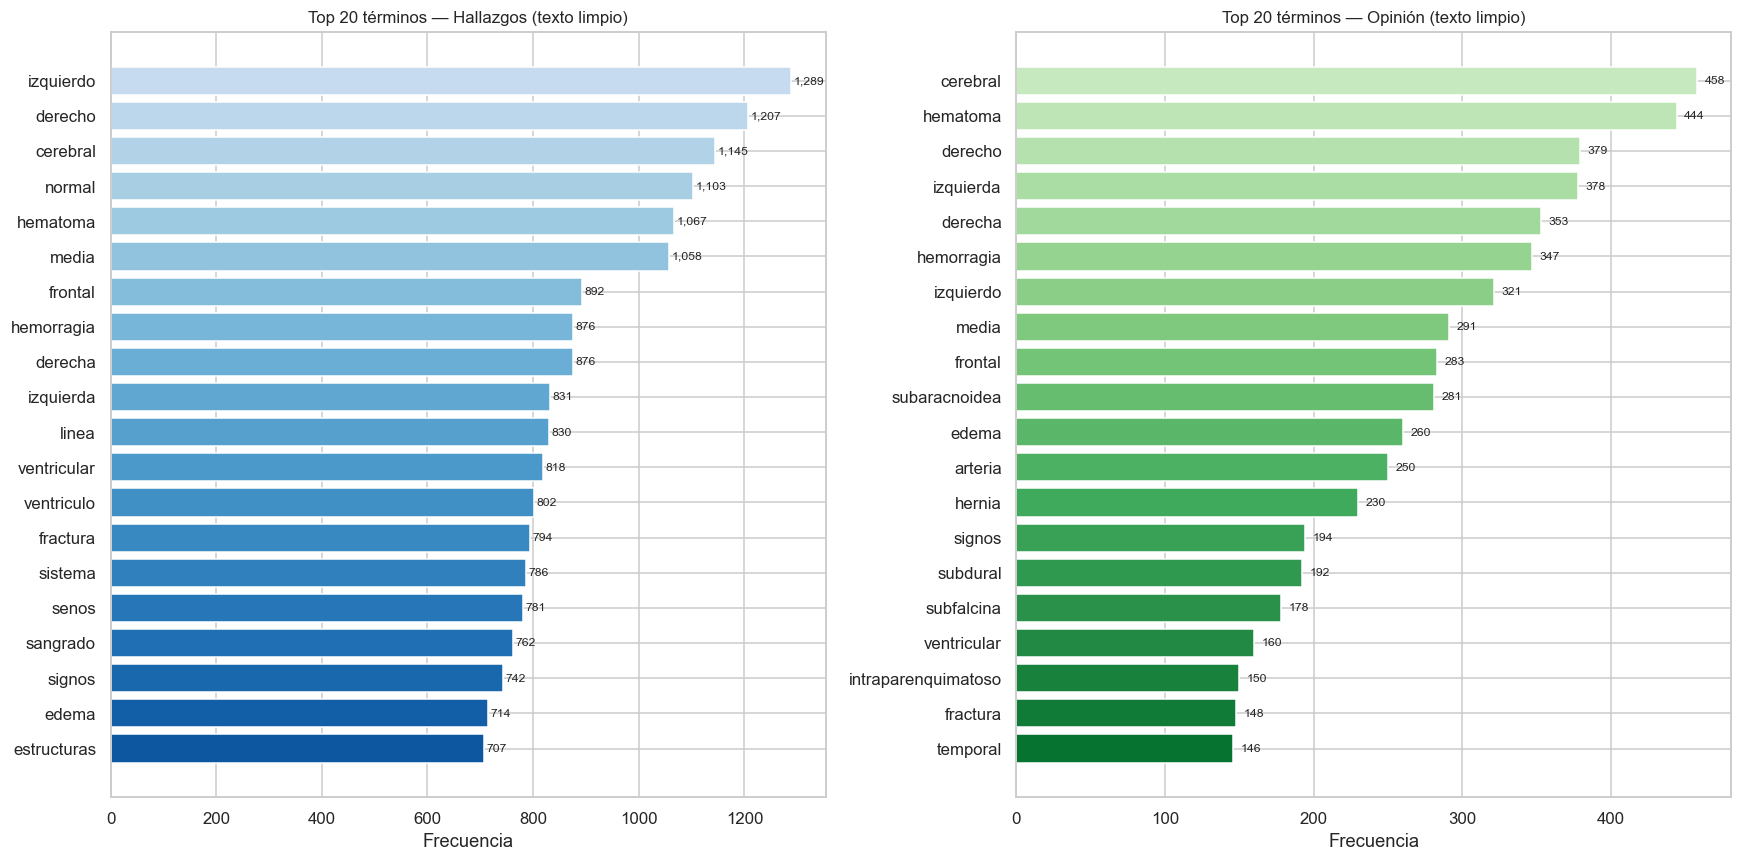

In [60]:
def plot_top_terms(corpus, titulo, n=20, cmap='viridis', ax=None):
    words   = corpus.split()
    counter = Counter(words)
    top     = counter.most_common(n)
    terms, freqs = zip(*top)
    colors = cm.get_cmap(cmap)(np.linspace(0.25, 0.85, n))
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.barh(terms[::-1], freqs[::-1], color=colors[::-1], edgecolor='white')
    for bar, freq in zip(bars, freqs[::-1]):
        ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                f'{freq:,}', va='center', fontsize=8)
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel('Frecuencia')

corpus_hallazgos = ' '.join(df['Hallazgos_limpio'].dropna())
corpus_opinion   = ' '.join(df['Opinion_limpio'].dropna())

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
plot_top_terms(corpus_hallazgos, 'Top 20 términos — Hallazgos (texto limpio)', cmap='Blues', ax=axes[0])
plot_top_terms(corpus_opinion,   'Top 20 términos — Opinión (texto limpio)',   cmap='Greens', ax=axes[1])
plt.tight_layout()
plt.show()

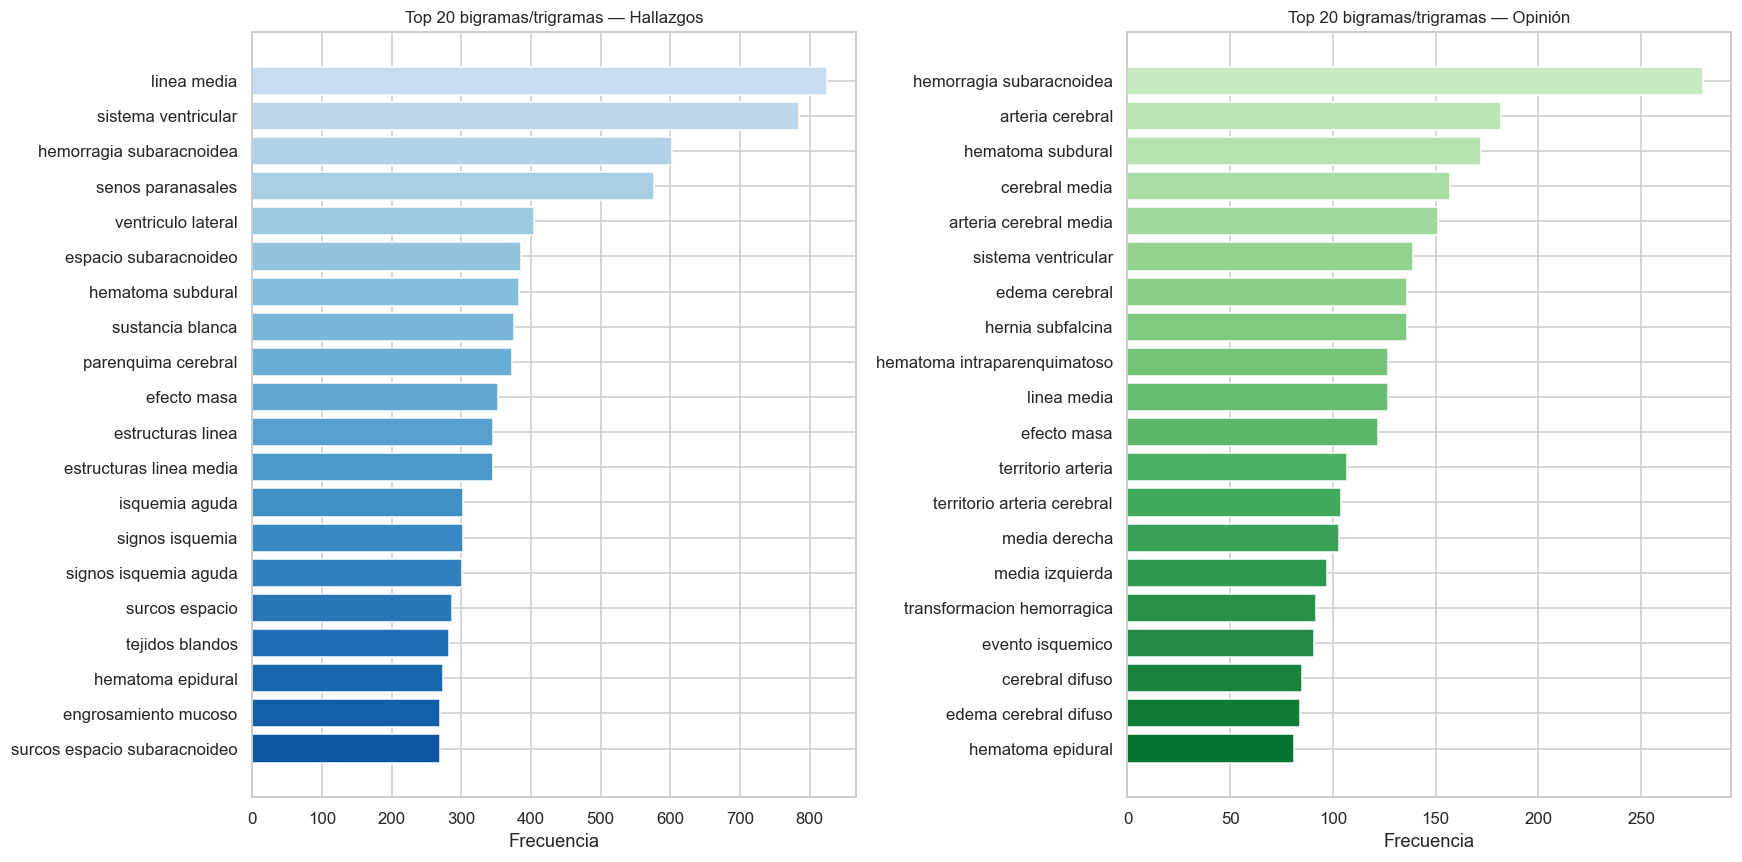

In [61]:
# N-gramas (2-3 palabras)
def top_ngrams(corpus, ngram_range=(2,3), n=20):
    vec = CountVectorizer(ngram_range=ngram_range, max_features=200)
    X   = vec.fit_transform([corpus])
    resultado = sorted(
        zip(vec.get_feature_names_out(), X.sum(axis=0).A1),
        key=lambda x: -x[1]
    )
    return resultado[:n]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, corpus, titulo, cmap in [
    (axes[0], corpus_hallazgos, 'Top 20 bigramas/trigramas — Hallazgos', 'Blues'),
    (axes[1], corpus_opinion,   'Top 20 bigramas/trigramas — Opinión',   'Greens'),
]:
    ngrams = top_ngrams(corpus)
    terms, freqs = zip(*ngrams)
    n = len(terms)
    colors = cm.get_cmap(cmap)(np.linspace(0.25, 0.85, n))
    ax.barh(terms[::-1], freqs[::-1], color=colors[::-1], edgecolor='white')
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel('Frecuencia')

plt.tight_layout()
plt.show()

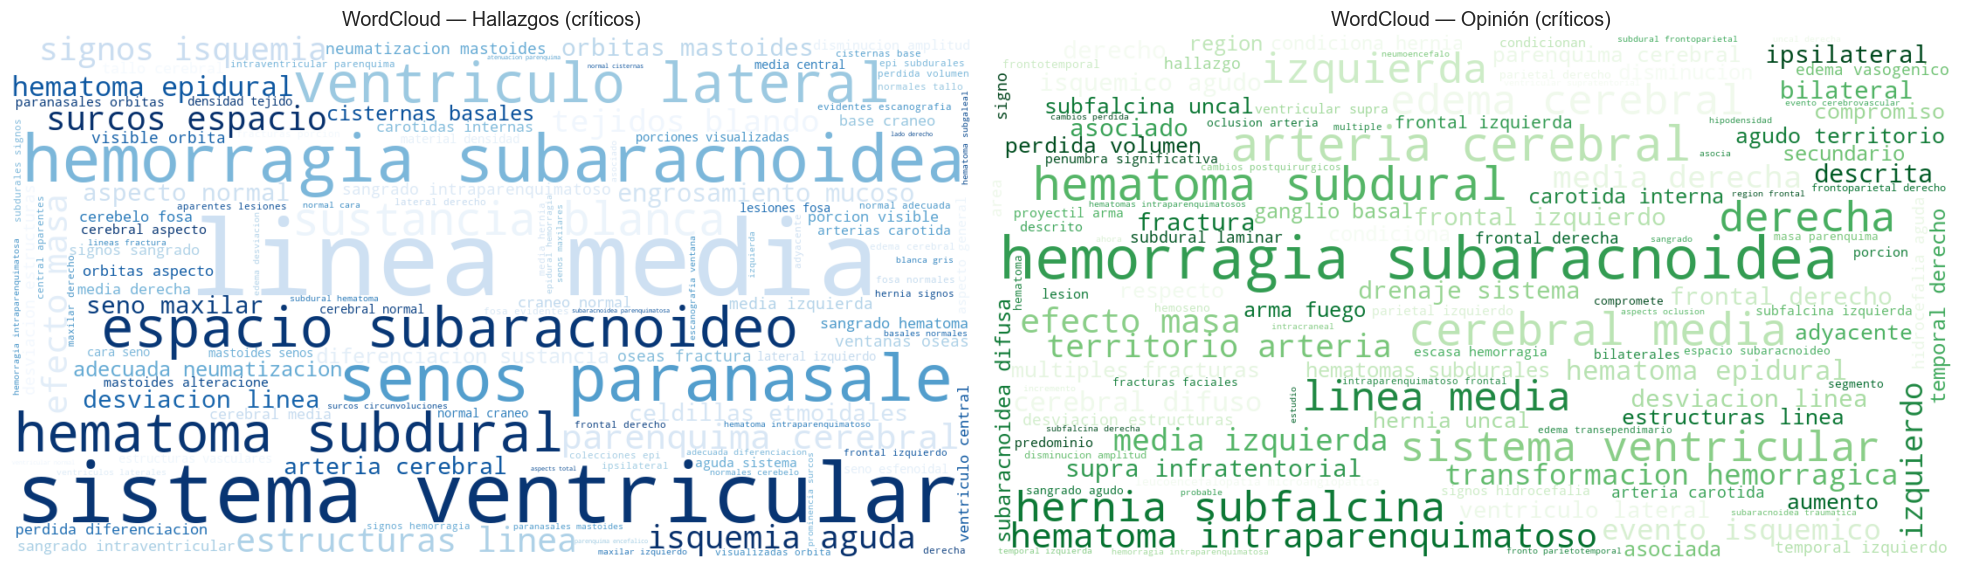

In [62]:
# Nubes de palabras
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, corpus, titulo, cmap in [
    (axes[0], corpus_hallazgos, 'WordCloud — Hallazgos (críticos)', 'Blues'),
    (axes[1], corpus_opinion,   'WordCloud — Opinión (críticos)',   'Greens'),
]:
    wc = WordCloud(width=1100, height=600, background_color='white',
                   colormap=cmap, max_words=120).generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(titulo, fontsize=13)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 9. Detección de patologías por reglas

In [63]:
# Misma función de detección robusta del cuaderno 0
KEYWORDS_NEGATIVOS_GLOBAL = [
    'antiguo','antigua','cronico','cronica','crónico','crónica',
    'viejo','vieja','residual','residuales','secuela','secuelar','secuelas',
    'previo','previa','previos','previas','conocido','conocida',
    'ya descrito','ya visualizado','sin cambios','estable','resolucion','resolución'
]

NEGACIONES_CONTEXTUALES = [
    'sin','descarta','descartado','descartada','negativo','negativa',
    'ausencia','ausente','ausentes','sin evidencia','sin signos',
    'no se observa','no se observan','no se evidencia','no se evidencian',
    'no se identifica','no se identifican','libre de','negativo para',
    'negativa para'
]

def detectar_patologia_robusta(texto, keywords_pos, keywords_neg=None):
    if not isinstance(texto, str):
        return 0
    texto = texto.lower()
    keywords_neg = keywords_neg or KEYWORDS_NEGATIVOS_GLOBAL
    kw_ord = sorted(keywords_pos, key=len, reverse=True)
    oraciones = re.split(r'[.;]', texto)
    for oracion in oraciones:
        oracion = oracion.strip()
        kw_encontrada = next((kw for kw in kw_ord if kw in oracion), None)
        if not kw_encontrada:
            continue
        if re.search(re.escape(kw_encontrada) + r'\s*:\s*no\b', oracion):
            continue
        if re.search(re.escape(kw_encontrada) + r'\s*:[^.;]*?\b(no|negativo|negativa|ausente)\b', oracion):
            continue
        idx_kw = oracion.find(kw_encontrada)
        segmento_previo = oracion[max(0, idx_kw-50):idx_kw]
        if any(neg in segmento_previo for neg in NEGACIONES_CONTEXTUALES):
            continue
        if re.search(r'sin\s+(hallazgos?|evidencia|signos?)\s+(indirectos?\s+)?(de\s+)?' + re.escape(kw_encontrada), oracion):
            continue
        if any(ant in oracion for ant in keywords_neg):
            continue
        if 'sin cambios' in oracion and kw_encontrada in oracion:
            continue
        return 1
    return 0


KW_HEMORRAGIA = [
    'hemorragia subaracnoidea','hematoma subdural','hematoma epidural',
    'sangrado intraparenquimatoso','sangrado intraventricular',
    'hemorragia intraparenquimatosa','hemorragia intraventricular',
    'foco hemorragico','focos hemorragicos','hemorragia','hematoma','sangrado',
]

KW_ACV = [
    'infarto cerebral','infarto lacunar','infartos lacunares',
    'evento isquemico','evento cerebrovascular','area de isquemia',
    'hipodensidad cortical','hipodensidad subcortical',
    'infarto','isquemia','isquemico','isquemica','ictus','acv',
]

KW_FRACTURA = [
    'fractura con hundimiento','fractura hundimiento','fractura deprimida',
    'fractura conminuta','fractura compleja','fractura de base de craneo',
    'fractura craneofacial','fractura multiple de craneo',
]

KW_DLM = [
    'desviacion de la linea media','desviacion linea media',
    'linea media desplazada','desplazamiento de la linea media',
    'shift de linea media','herniacion subfalcina','hernia subfalcina',
]

df['hemorragia']              = df['Hallazgos'].apply(lambda x: detectar_patologia_robusta(x, KW_HEMORRAGIA))
df['acv']                     = df['Hallazgos'].apply(lambda x: detectar_patologia_robusta(x, KW_ACV))
df['fractura_compleja_craneo']= df['Hallazgos'].apply(lambda x: detectar_patologia_robusta(x, KW_FRACTURA))
df['desviacion_linea_media']  = df['Hallazgos'].apply(lambda x: detectar_patologia_robusta(x, KW_DLM))

patologias = ['hemorragia','acv','fractura_compleja_craneo','desviacion_linea_media']
for p in patologias:
    n_pos = df[p].sum()
    print(f'{p:<30}: {n_pos:>4} casos ({100*n_pos/len(df):.1f}%)')

hemorragia                    :  771 casos (81.0%)
acv                           :  426 casos (44.7%)
fractura_compleja_craneo      :   29 casos (3.0%)
desviacion_linea_media        :   46 casos (4.8%)


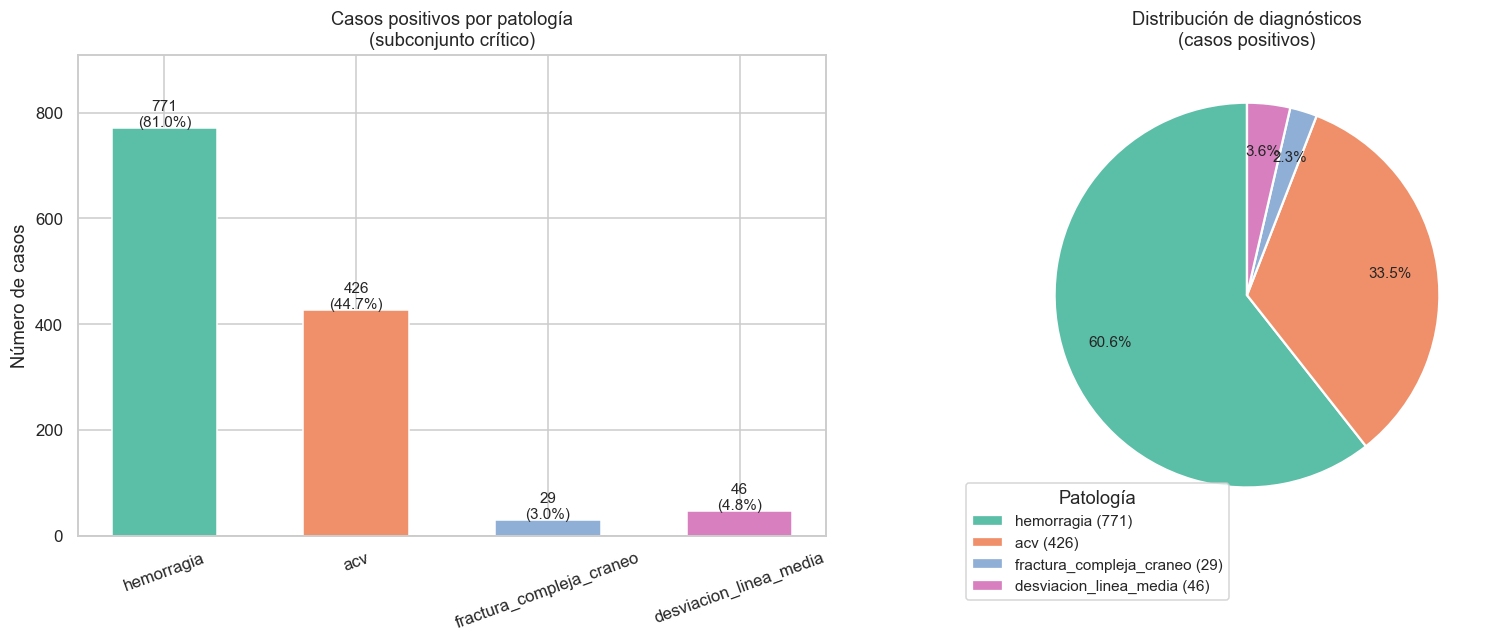

In [64]:
# Gráfico de barras por patología
conteos = {p: int(df[p].sum()) for p in patologias}
colores = ['#5bbfa8','#f0906a','#8fafd6','#d87fbf']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Barras
bars = axes[0].bar(conteos.keys(), conteos.values(), color=colores, edgecolor='white', width=0.55)
for bar, v in zip(bars, conteos.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 f'{v}\n({100*v/len(df):.1f}%)', ha='center', fontsize=10)
axes[0].set_title('Casos positivos por patología\n(subconjunto crítico)', fontsize=12)
axes[0].set_ylabel('Número de casos')
axes[0].tick_params(axis='x', rotation=20)
axes[0].set_ylim(0, max(conteos.values()) * 1.18)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    conteos.values(), labels=None, autopct='%1.1f%%',
    colors=colores, startangle=90, pctdistance=0.75,
    wedgeprops={'linewidth':1.5, 'edgecolor':'white'}
)
for at in autotexts:
    at.set_fontsize(10)
axes[1].legend(
    wedges, [f'{k} ({v})' for k,v in conteos.items()],
    title='Patología', loc='lower left', bbox_to_anchor=(-0.1, -0.15), fontsize=10
)
axes[1].set_title('Distribución de diagnósticos\n(casos positivos)', fontsize=12)

plt.tight_layout()
plt.show()

Distribución de registros por número de patologías detectadas:
n_patologias
0    149
1    368
2    402
3     32
4      1
Name: count, dtype: int64


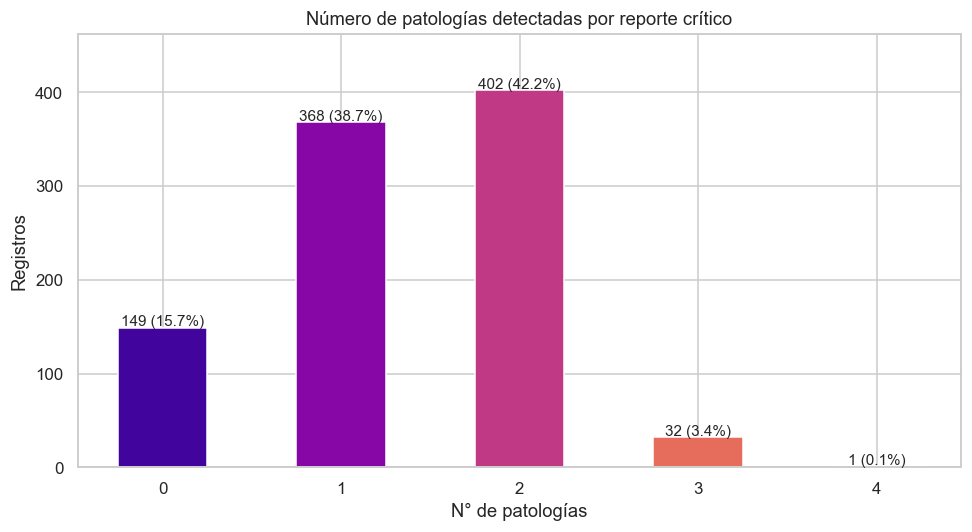

In [65]:
# Distribución multilabel
df['n_patologias'] = df[patologias].sum(axis=1)

print('Distribución de registros por número de patologías detectadas:')
print(df['n_patologias'].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(9, 5))
vc = df['n_patologias'].value_counts().sort_index()
ax.bar(vc.index.astype(str), vc.values,
       color=cm.plasma(np.linspace(0.1, 0.8, len(vc))), edgecolor='white', width=0.5)
for i, v in enumerate(vc.values):
    ax.text(i, v + 2, f'{v} ({100*v/len(df):.1f}%)', ha='center', fontsize=10)
ax.set_title('Número de patologías detectadas por reporte crítico', fontsize=12)
ax.set_xlabel('N° de patologías')
ax.set_ylabel('Registros')
ax.set_ylim(0, vc.max() * 1.15)
plt.tight_layout()
plt.show()

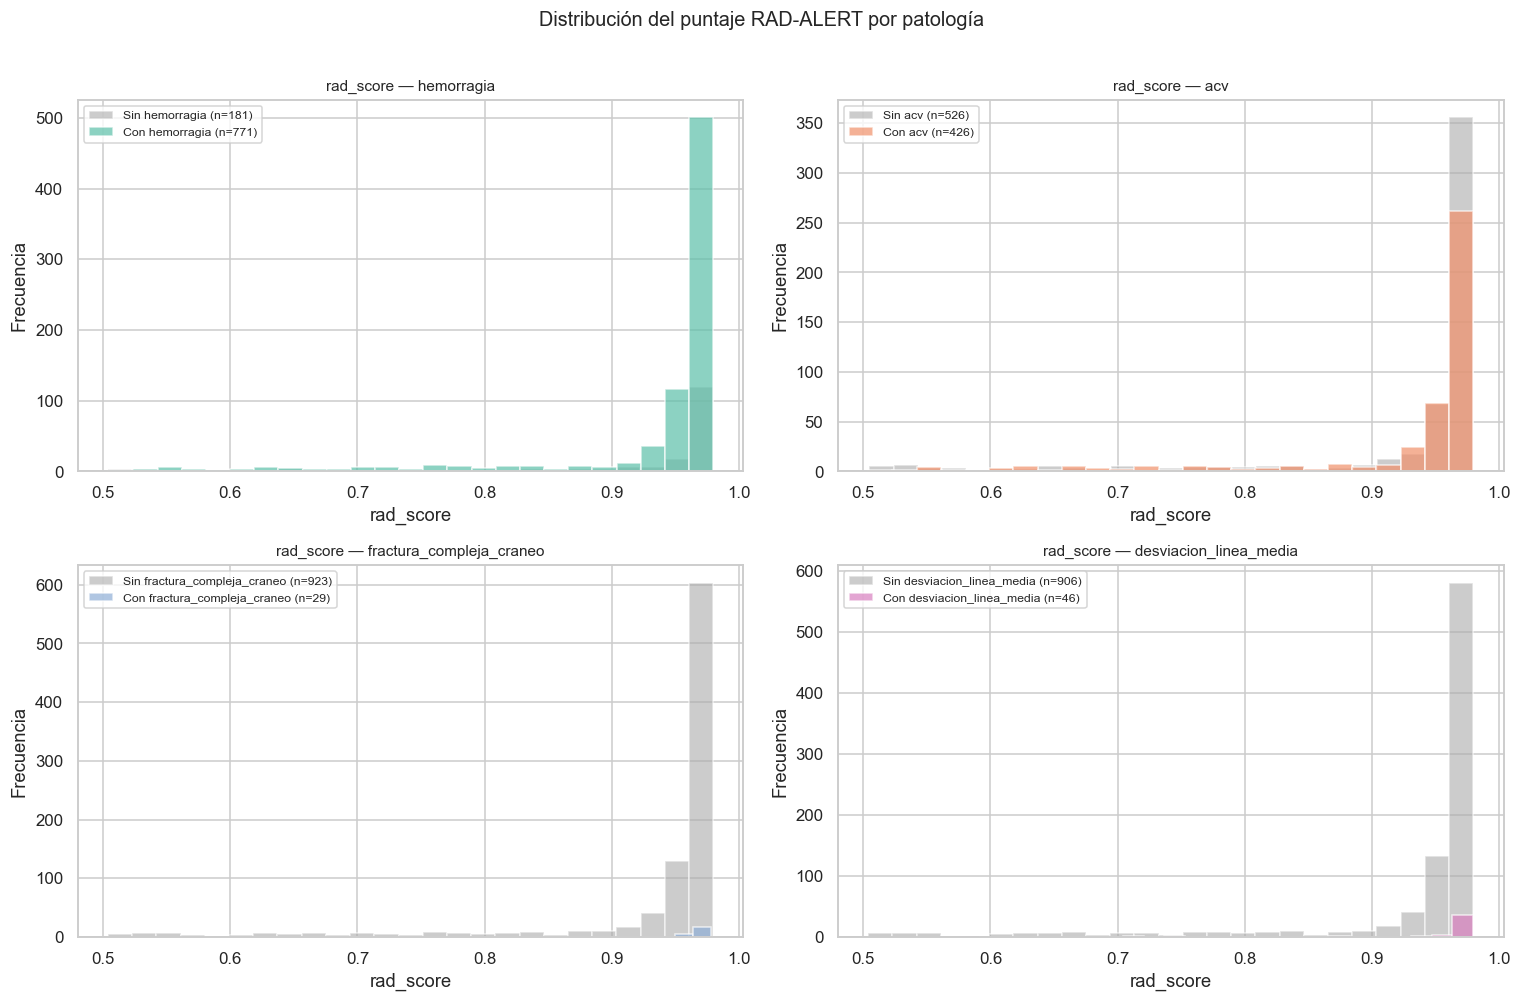

In [66]:
# rad_score por patología
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, pat, color in zip(axes, patologias, colores):
    pos = df[df[pat] == 1]['rad_score']
    neg = df[df[pat] == 0]['rad_score']
    ax.hist(neg, bins=25, alpha=0.6, color='#aaaaaa', edgecolor='white', label=f'Sin {pat} (n={len(neg)})')
    ax.hist(pos, bins=25, alpha=0.7, color=color,     edgecolor='white', label=f'Con {pat} (n={len(pos)})')
    ax.set_title(f'rad_score — {pat}', fontsize=10)
    ax.set_xlabel('rad_score')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

plt.suptitle('Distribución del puntaje RAD-ALERT por patología', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 10. Co-ocurrencia y correlaciones

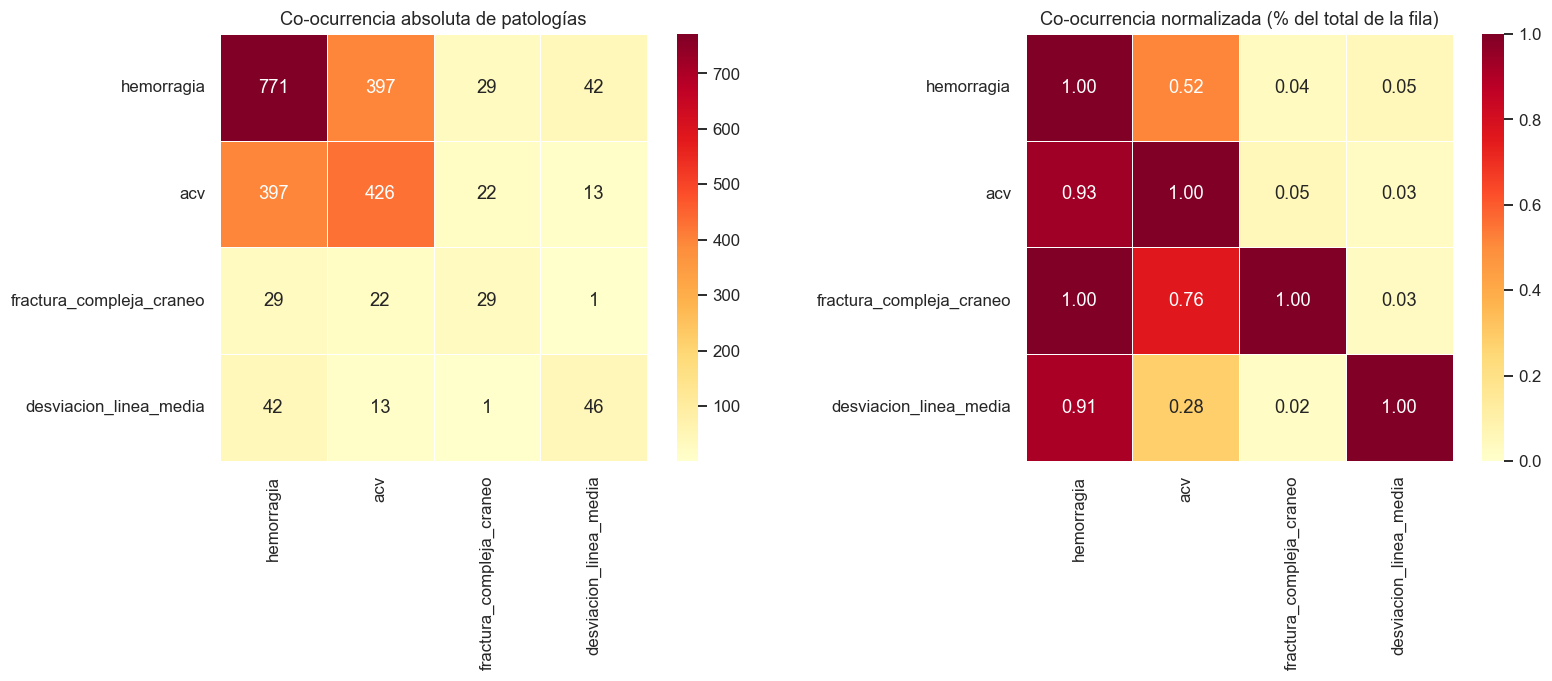

In [67]:
# Heatmap de co-ocurrencia entre patologías
cooc = df[patologias].T.dot(df[patologias])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Conteo absoluto
sns.heatmap(cooc, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, ax=axes[0], square=True)
axes[0].set_title('Co-ocurrencia absoluta de patologías', fontsize=12)

# Normalizado por diagonal (% de casos de fila que también tienen columna)
diag  = np.diag(cooc.values)
cooc_norm = cooc.div(diag, axis=0).round(3)
sns.heatmap(cooc_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[1], square=True, vmin=0, vmax=1)
axes[1].set_title('Co-ocurrencia normalizada (% del total de la fila)', fontsize=12)

plt.tight_layout()
plt.show()

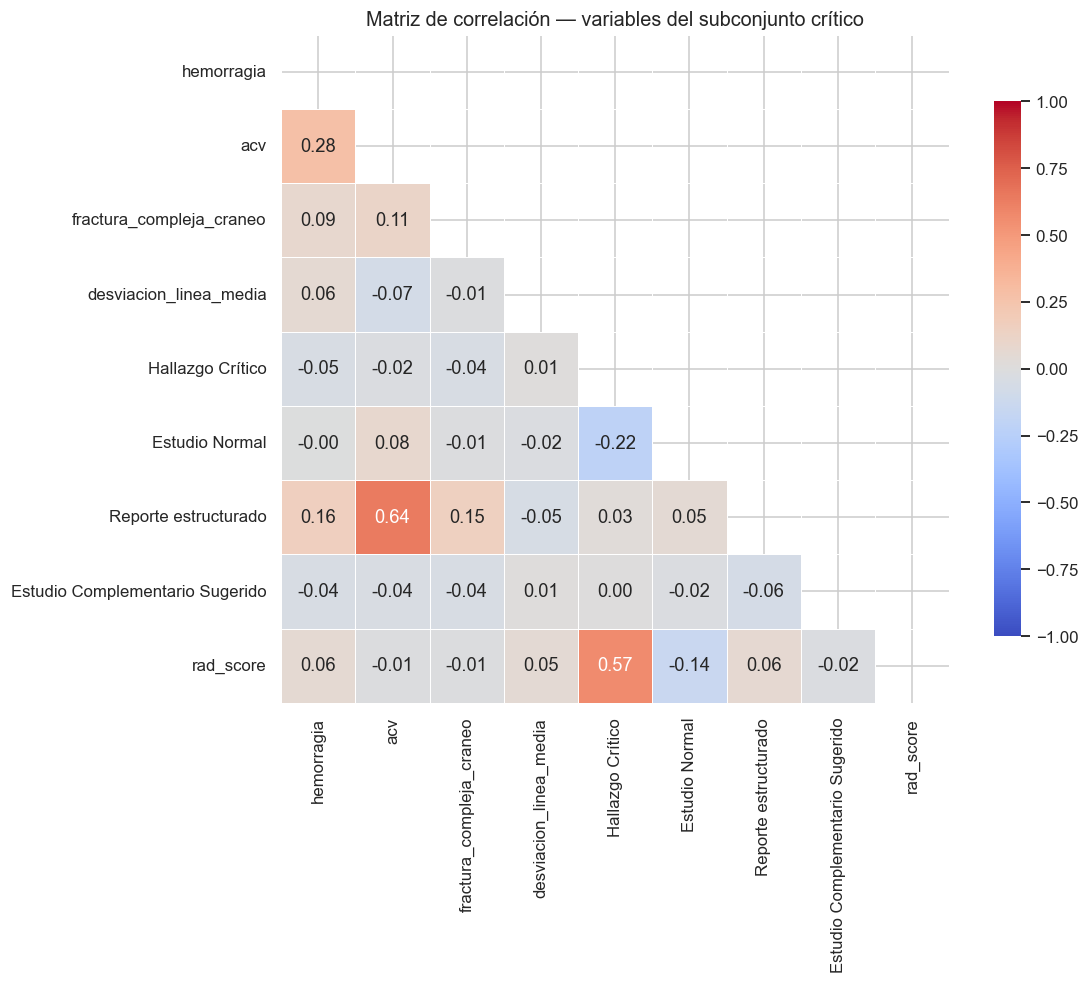

In [68]:
# Matriz de correlación (variables numéricas + binarias)
cols_corr = patologias + ['Hallazgo Crítico', 'Estudio Normal',
                           'Reporte estructurado', 'Estudio Complementario Sugerido',
                           'rad_score']

df_corr = df[cols_corr].copy()
df_corr['Estudio Normal'] = pd.to_numeric(df_corr['Estudio Normal'], errors='coerce')

corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    vmin=-1, vmax=1, square=True, ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Matriz de correlación — variables del subconjunto crítico', fontsize=13)
plt.tight_layout()
plt.show()

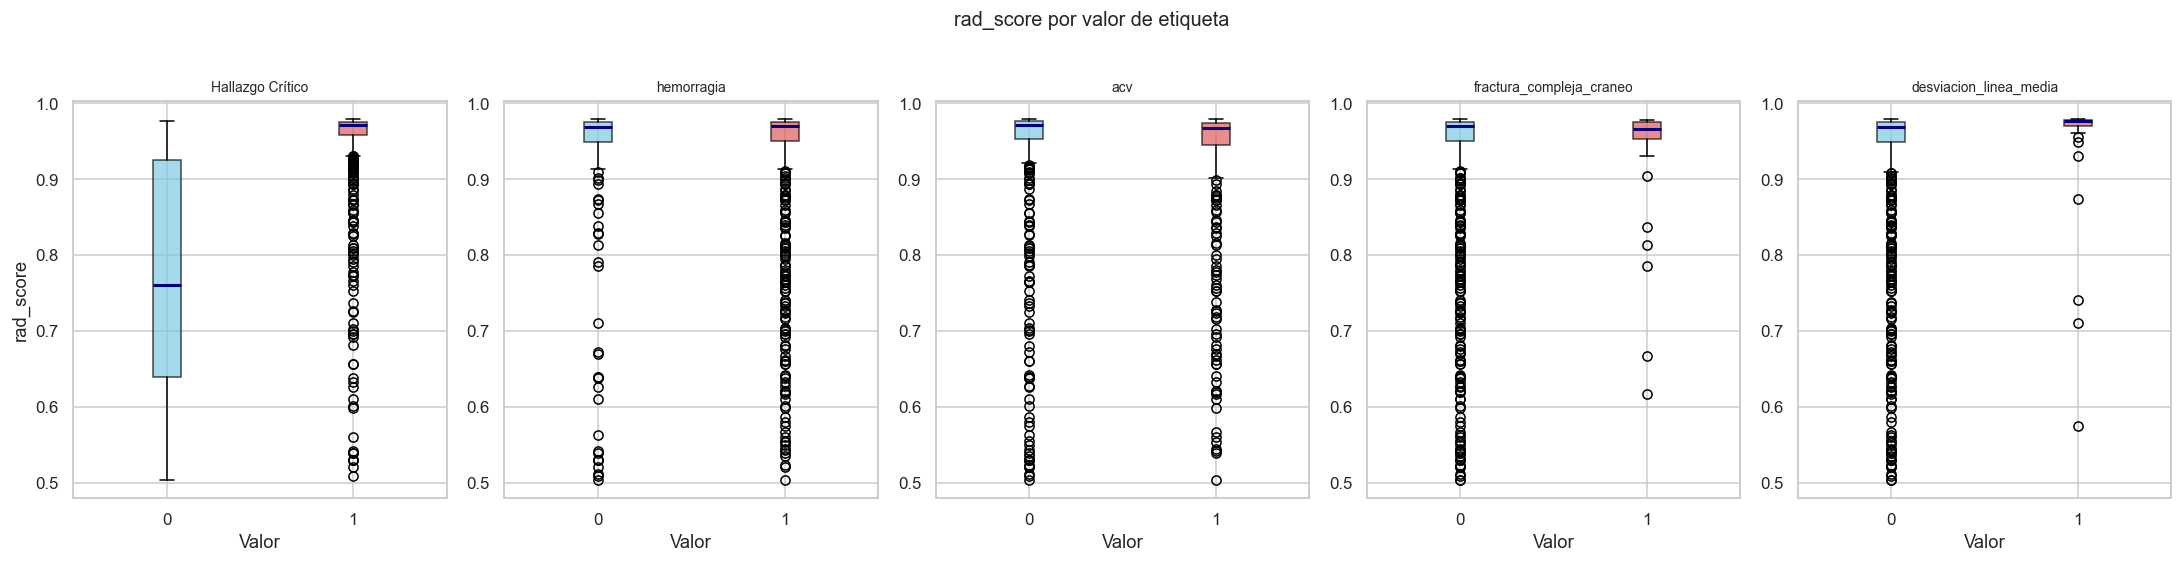

In [69]:
# Comparar rad_score entre etiquetas de Hallazgo Crítico y cada patología
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

etiquetas = ['Hallazgo Crítico'] + patologias
for ax, col in zip(axes, etiquetas):
    data_plot = [df[df[col] == v]['rad_score'].dropna() for v in [0, 1]]
    bp = ax.boxplot(data_plot, patch_artist=True,
                    labels=['0','1'],
                    boxprops=dict(alpha=0.7),
                    medianprops=dict(color='navy', linewidth=2))
    bp['boxes'][0].set_facecolor('#7ec8e3')
    bp['boxes'][1].set_facecolor('#e05c5c')
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('Valor')
    ax.set_ylabel('rad_score' if col == 'Hallazgo Crítico' else '')

plt.suptitle('rad_score por valor de etiqueta', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [70]:
# Resumen final
print('=' * 55)
print('     RESUMEN DEL SUBCONJUNTO RAD_CRITICOS')
print('=' * 55)
print(f'Total de registros              : {len(df)}')
print(f'Acuerdo con Hallazgo Crítico=1  : {int(df["Hallazgo Crítico"].sum())} ({100*df["Hallazgo Crítico"].mean():.1f}%)')
print(f'rad_score media                 : {df["rad_score"].mean():.3f}')
print(f'rad_score mediana               : {df["rad_score"].median():.3f}')
print()
print('Patologías detectadas por reglas:')
for p in patologias:
    n = int(df[p].sum())
    print(f'  {p:<33}: {n:>4} ({100*n/len(df):.1f}%)')
print()
print('Registros sin ninguna patología :', int((df['n_patologias'] == 0).sum()),
      f'({100*(df["n_patologias"]==0).mean():.1f}%)')
print('Registros con ≥2 patologías     :', int((df['n_patologias'] >= 2).sum()),
      f'({100*(df["n_patologias"]>=2).mean():.1f}%)')

     RESUMEN DEL SUBCONJUNTO RAD_CRITICOS
Total de registros              : 952
Acuerdo con Hallazgo Crítico=1  : 856 (89.9%)
rad_score media                 : 0.932
rad_score mediana               : 0.970

Patologías detectadas por reglas:
  hemorragia                       :  771 (81.0%)
  acv                              :  426 (44.7%)
  fractura_compleja_craneo         :   29 (3.0%)
  desviacion_linea_media           :   46 (4.8%)

Registros sin ninguna patología : 149 (15.7%)
Registros con ≥2 patologías     : 435 (45.7%)
